# CIS 5370 Final Project

## Project 1 - Intrusion Detection for Industrial Control Systems

- Kyle Brindle
- Rayhan Alcena

In [112]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.ensemble import IsolationForest
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Loading Files

In [113]:
# Base path to the datasets
BASE_PATH = Path.cwd() / "data/SWaT_A6_Dec_2019/"
SENSOR_READINGS_PATH = BASE_PATH / "csv/"
NETWORK_READINGS_PATH = BASE_PATH / "pcap/"

# Sensor Readings CSV/XLSX file paths
dec_2019_file_path = SENSOR_READINGS_PATH / "Dec2019.xlsx"

# Network Readings CSV/XLSX file paths

# Loading the CSV/XLSX files (We had to skip the first 9 rows (0-9))
sensor_readings_df = pd.read_excel(dec_2019_file_path, skiprows=9)

In [114]:
# Shows the first 10 observations in the dataframe
sensor_readings_df.head(10)

,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,...,FIT601.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm
0,2019-12-06 10:05:00,3,658.661255,0.0,1,2.0,1,2,2.313523,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
1,2019-12-06 10:05:01,3,659.171600,0.0,1,2.0,1,2,2.311857,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
2,2019-12-06 10:05:02,3,659.681800,0.0,1,2.0,1,2,2.311601,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
3,2019-12-06 10:05:03,3,660.349100,0.0,1,2.0,1,2,2.310448,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
4,2019-12-06 10:05:04,3,660.780945,0.0,1,2.0,1,2,2.310448,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
5,2019-12-06 10:05:05,3,661.016400,0.0,1,2.0,1,2,2.311088,35.087160,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
6,2019-12-06 10:05:06,3,661.055700,0.0,1,2.0,1,2,2.316086,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
7,2019-12-06 10:05:07,3,661.330444,0.0,1,2.0,1,2,2.317624,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
8,2019-12-06 10:05:08,3,661.369700,0.0,1,2.0,1,2,2.321469,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
9,2019-12-06 10:05:09,3,661.644500,0.0,1,2.0,1,2,2.325057,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active


## Preprocessing

In [115]:
# Separating the timestamps
t_stamp_sensor_readings_df = sensor_readings_df["t_stamp"]
print(t_stamp_sensor_readings_df)

0       2019-12-06 10:05:00
1       2019-12-06 10:05:01
2       2019-12-06 10:05:02
3       2019-12-06 10:05:03
4       2019-12-06 10:05:04
                ...        
13196   2019-12-06 13:44:56
13197   2019-12-06 13:44:57
13198   2019-12-06 13:44:58
13199   2019-12-06 13:44:59
13200   2019-12-06 13:45:00
Name: t_stamp, Length: 13201, dtype: datetime64[us]


In [116]:
# Identifying alarm columns for encoding
alarm_cols = [col for col in sensor_readings_df.columns if "Alarm" in col]
print("Alarm columns:", alarm_cols)

# Encoding alarm columns where Active = 1, Inactive = 0
for col in alarm_cols:
    sensor_readings_df[col] = (sensor_readings_df[col] == "Active").astype(int)

Alarm columns: ['LS201.Alarm', 'LS202.Alarm', 'LSL203.Alarm', 'LSLL203.Alarm', 'PSH301.Alarm', 'DPSH301.Alarm', 'LS401.Alarm', 'PSH501.Alarm', 'PSL501.Alarm', 'LSH601.Alarm', 'LSL601.Alarm', 'LSH602.Alarm', 'LSL602.Alarm', 'LSH603.Alarm', 'LSL603.Alarm']


In [117]:
# Creating a label column where Normal = 0, Attack = 1
sensor_readings_df["label"] = 0

# Attack windows for sensor/actuator disruption
# Format: YYYY-MM-DD HH:MM:SS
attack_windows = [
    ("2019-12-06 12:30:00", "2019-12-06 12:33:00"),
    ("2019-12-06 12:43:00", "2019-12-06 12:46:00"),
    ("2019-12-06 12:56:00", "2019-12-06 12:59:00"),
    ("2019-12-06 13:09:00", "2019-12-06 13:12:00"),
    ("2019-12-06 13:22:00", "2019-12-06 13:25:00"),
]

# Setting the label column for each observation as Normal or an Attack
# Based on the timestamp
for start, end in attack_windows:
    mask = (sensor_readings_df["t_stamp"] >= start) & (sensor_readings_df["t_stamp"] <= end)
    sensor_readings_df.loc[mask, "label"] = 1

# Verifying the label column
print(sensor_readings_df["label"].value_counts())
print(f"Attack: {sensor_readings_df["label"].mean() * 100}%")

label
0    12296
1      905
Name: count, dtype: int64
Attack: 6.855541246875236%


## Sensor Readings Evaluations

### Train/Test Split Based on the Timeline

In [118]:
# Setting up the training data with Normal sensor operations before the attack
train_sensor_readings_df = sensor_readings_df[t_stamp_sensor_readings_df < "2019-12-06 12:30:00"].drop(columns=["t_stamp", "label"])

# Setting up the testing data with the Full sensor operations, includes both Normal and Attack labels
test_sensor_readings_df = sensor_readings_df.drop(columns="t_stamp")
test_sensor_readings_labels = test_sensor_readings_df.pop("label")

print("Train shape:", train_sensor_readings_df.shape)
print("Test shape:", test_sensor_readings_df.shape)
print("Attack samples in test:", test_sensor_readings_labels.sum())

Train shape: (8700, 81)
Test shape: (13201, 81)
Attack samples in test: 905


### Normalization and Modeling

In [119]:
# Initializing the MinMaxScaler
scaler = MinMaxScaler()

# Fitting the training data
X_train_sensor_readings_df = scaler.fit_transform(train_sensor_readings_df)

# Testing
X_test_sensor_readings_df = scaler.transform(test_sensor_readings_df)
Y_test_sensor_readings_labels = test_sensor_readings_labels.values

print("X_train shape:", X_train_sensor_readings_df.shape)
print("X_test shape:", X_test_sensor_readings_df.shape)

X_train shape: (8700, 81)
X_test shape: (13201, 81)


#### Model 1 - Statistical Threshold

In [ ]:
# Computing the mean and standard deviation from the training data
mean_train_sensor_readings =  X_train_sensor_readings_df.mean(axis=0)
std_train_sensor_readings =  X_train_sensor_readings_df.std(axis=0)

# Flag  anamoly if any feature exceeds the mean plus/minus 3 times the standard deviation
z_scores = np.abs((X_test_sensor_readings_df - mean_train_sensor_readings) / (std_train_sensor_readings + 1e-8))

# Max z-score per row
anomaly_scores = z_scores.max(axis=1)

# Replace NaN in anomaly scores with 0
anomaly_scores = np.nan_to_num(anomaly_scores, nan=0.0)

# Predictions
threshold_predictions = (anomaly_scores > 3).astype(int)

# Evaluate
print("=== Statistical Threshold ===")
print(classification_report(Y_test_sensor_readings_labels, threshold_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, anomaly_scores))

=== Statistical Threshold ===
              precision    recall  f1-score   support

           0       0.96      0.62      0.75     12296
           1       0.11      0.62      0.18       905

    accuracy                           0.62     13201
   macro avg       0.53      0.62      0.47     13201
weighted avg       0.90      0.62      0.72     13201

AUC: 0.6921661628270613


In [121]:
# Training the IsolationForest Model
iso = IsolationForest(contamination=0.069, random_state=42, n_estimators=100)
iso.fit(X_train_sensor_readings_df)

# Predicting whether the IsolationForest model returns 1 (normal) and -1 (attack)
iso_predictions_raw = iso.predict(X_test_sensor_readings_df)

# Convert to 0 (normal) and 1 (attack)
iso_predictions = (iso_predictions_raw == -1).astype(int)

# Scores for AUC (lower score = more anomalous)
iso_scores = -iso.decision_function(X_test_sensor_readings_df)

# Evaluate
print("=== Isolation Forest ===")
print(classification_report(Y_test_sensor_readings_labels, iso_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, iso_scores))

=== Isolation Forest ===
              precision    recall  f1-score   support

           0       0.98      0.77      0.86     12296
           1       0.20      0.75      0.31       905

    accuracy                           0.77     13201
   macro avg       0.59      0.76      0.59     13201
weighted avg       0.92      0.77      0.83     13201

AUC: 0.8335890573945801


In [ ]:
# Fixed random seeds for reproducibility purposes
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

# Fixing any NaNs in the test data before converting it to a tensor
X_train_sensor_readings_df = pd.DataFrame(X_train_sensor_readings_df).ffill().bfill().values
X_test_sensor_readings_df = pd.DataFrame(X_test_sensor_readings_df).ffill().bfill().values

# Converting the training and testing data to tensors
X_train_sensor_readings_tensor = torch.FloatTensor(X_train_sensor_readings_df)
X_test_sensor_readings_tensor = torch.FloatTensor(X_test_sensor_readings_df)

# Verifing that there are no NaNs
print("X_train NaNs:", torch.isnan(X_train_sensor_readings_tensor).sum().item())
print("X_test NaNs:", torch.isnan(X_test_sensor_readings_tensor).sum().item())

train_sensor_readings_dataset = TensorDataset(X_train_sensor_readings_tensor, X_train_sensor_readings_tensor)
train_sensor_readings_loader = DataLoader(train_sensor_readings_dataset, batch_size=64, shuffle=False)

# Autoencoder Architecture
input_dim = X_train_sensor_readings_df.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Initializing torch to use Cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

autoencoder = Autoencoder(input_dim).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Training the Autoencoder Model
epochs = 50
for epoch in range(epochs):
    autoencoder.train()
    total_loss = 0
    for batch_x, batch_y in train_sensor_readings_loader:
        batch_x = batch_x.to(device)
        reconstructed = autoencoder(batch_x)
        loss = criterion(reconstructed, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_sensor_readings_loader):.6f}")

# Threshold from training reconstruction error
autoencoder.eval()
with torch.no_grad():
    reconstructed_train = autoencoder(X_train_sensor_readings_tensor.to(device))
    train_reconstruction_errors = torch.mean(
        (X_train_sensor_readings_tensor.to(device) - reconstructed_train) ** 2, dim=1
    ).cpu().numpy()

ae_threshold = np.percentile(train_reconstruction_errors, 95)
print(f"\nAutoencoder threshold (95th percentile): {ae_threshold:.6f}")

# Reconstruction error on test set
with torch.no_grad():
    reconstructed_test = autoencoder(X_test_sensor_readings_tensor.to(device))
    ae_reconstruction_errors = torch.mean(
        (X_test_sensor_readings_tensor.to(device) - reconstructed_test) ** 2, dim=1
    ).cpu().numpy()

# Verifing any errors
print("Reconstruction errors NaNs:", np.isnan(ae_reconstruction_errors).sum())
print("Reconstruction errors shape:", ae_reconstruction_errors.shape)

# Predictions
ae_predictions = (ae_reconstruction_errors > ae_threshold).astype(int)

# Evaluate
print("=== Autoencoder ===")
print(classification_report(Y_test_sensor_readings_labels, ae_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, ae_reconstruction_errors))

X_train NaNs: 0
X_test NaNs: 0
Using device: cuda
Epoch 10/50 | Loss: 0.026410
Epoch 20/50 | Loss: 0.019182
Epoch 30/50 | Loss: 0.018308
Epoch 40/50 | Loss: 0.014508
Epoch 50/50 | Loss: 0.010706

Autoencoder threshold (95th percentile): 0.024633
Reconstruction errors NaNs: 0
Reconstruction errors shape: (13201,)
=== Autoencoder ===
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     12296
           1       0.16      0.38      0.23       905

    accuracy                           0.82     13201
   macro avg       0.55      0.62      0.56     13201
weighted avg       0.90      0.82      0.85     13201

AUC: 0.7593972975984643


In [123]:
# Finding other threshold percentile
for p in [90, 92, 95, 97, 99]:
    preds = (ae_reconstruction_errors > np.percentile(train_reconstruction_errors, p)).astype(int)
    print(f"Percentile {p} | F1: {f1_score(Y_test_sensor_readings_labels, preds):.3f}")

Percentile 90 | F1: 0.232
Percentile 92 | F1: 0.223
Percentile 95 | F1: 0.225
Percentile 97 | F1: 0.251
Percentile 99 | F1: 0.321


In [124]:
# Finding other threshold percentile around 99
for p in [98, 99, 99.5, 99.7, 99.9]:
    preds = (ae_reconstruction_errors > np.percentile(train_reconstruction_errors, p)).astype(int)
    print(f"Percentile {p} | F1: {f1_score(Y_test_sensor_readings_labels, preds):.3f}")

Percentile 98 | F1: 0.296
Percentile 99 | F1: 0.321
Percentile 99.5 | F1: 0.309
Percentile 99.7 | F1: 0.272
Percentile 99.9 | F1: 0.254


In [125]:
# Evaluating the model using 99th percentile threshold
ae_threshold = np.percentile(train_reconstruction_errors, 99)
ae_predictions = (ae_reconstruction_errors > ae_threshold).astype(int)

print("=== Autoencoder (tuned threshold @ 99th percentile) ===")
print(classification_report(Y_test_sensor_readings_labels, ae_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, ae_reconstruction_errors))

=== Autoencoder (tuned threshold @ 99th percentile) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     12296
           1       0.32      0.32      0.32       905

    accuracy                           0.91     13201
   macro avg       0.63      0.64      0.64     13201
weighted avg       0.91      0.91      0.91     13201

AUC: 0.7593972975984643


## Sensor Readings Visualizations

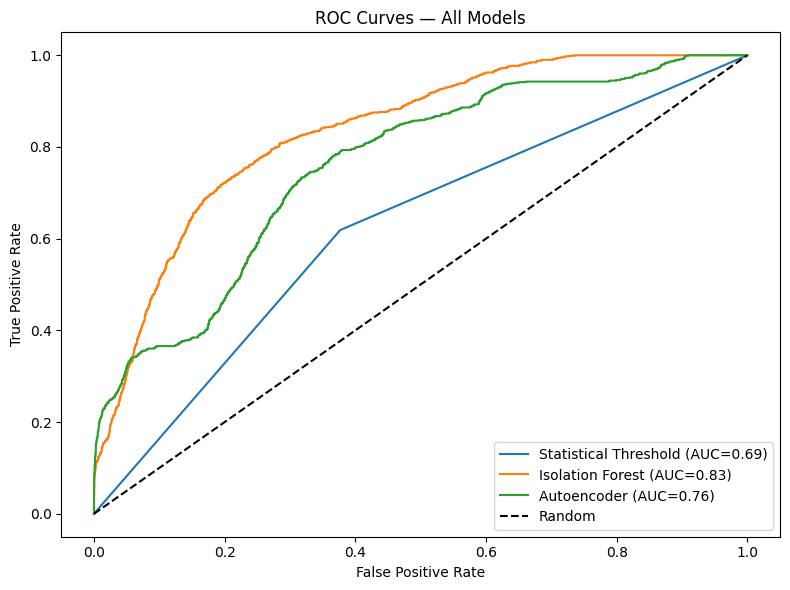

In [126]:
# ROC Curves of each model on one plot
fig, ax = plt.subplots(figsize=(8, 6))

fpr_st, tpr_st, _ = roc_curve(Y_test_sensor_readings_labels, threshold_predictions)
fpr_if, tpr_if, _ = roc_curve(Y_test_sensor_readings_labels, iso_scores)
fpr_ae, tpr_ae, _ = roc_curve(Y_test_sensor_readings_labels, ae_reconstruction_errors)

ax.plot(fpr_st, tpr_st, label="Statistical Threshold (AUC=0.69)")
ax.plot(fpr_if, tpr_if, label="Isolation Forest (AUC=0.83)")
ax.plot(fpr_ae, tpr_ae, label="Autoencoder (AUC=0.76)")
ax.plot([0, 1], [0, 1], "k--", label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend()
plt.tight_layout()
plt.savefig("results/sensor_readings/roc_curves.png", dpi=150)
plt.show()

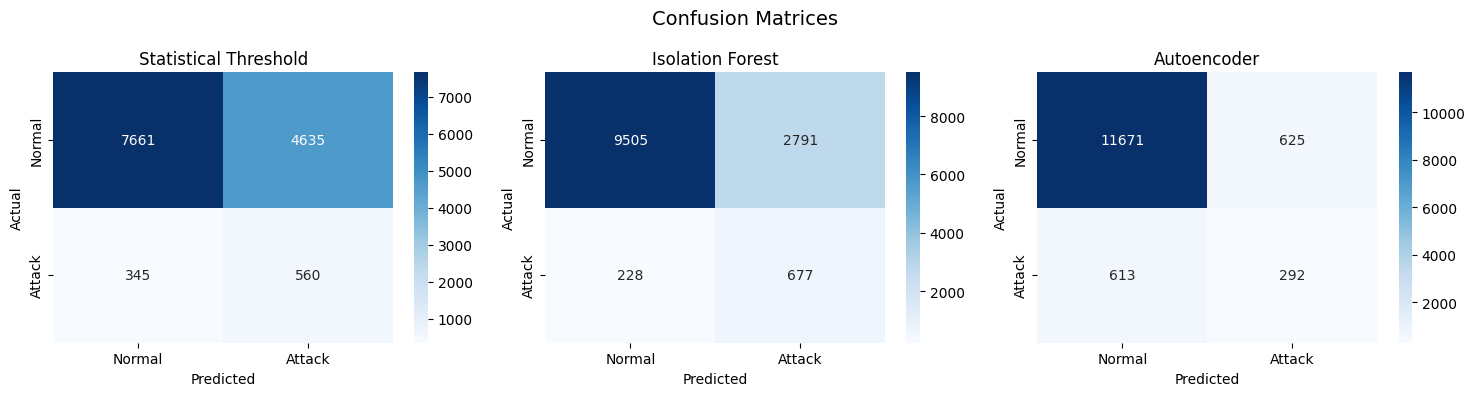

In [127]:
# Confusion Matrices for each model side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Statistical Threshold", threshold_predictions),
    ("Isolation Forest", iso_predictions),
    ("Autoencoder", ae_predictions),
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(Y_test_sensor_readings_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.savefig("results/sensor_readings/confusion_matrices.png", dpi=150)
plt.show()

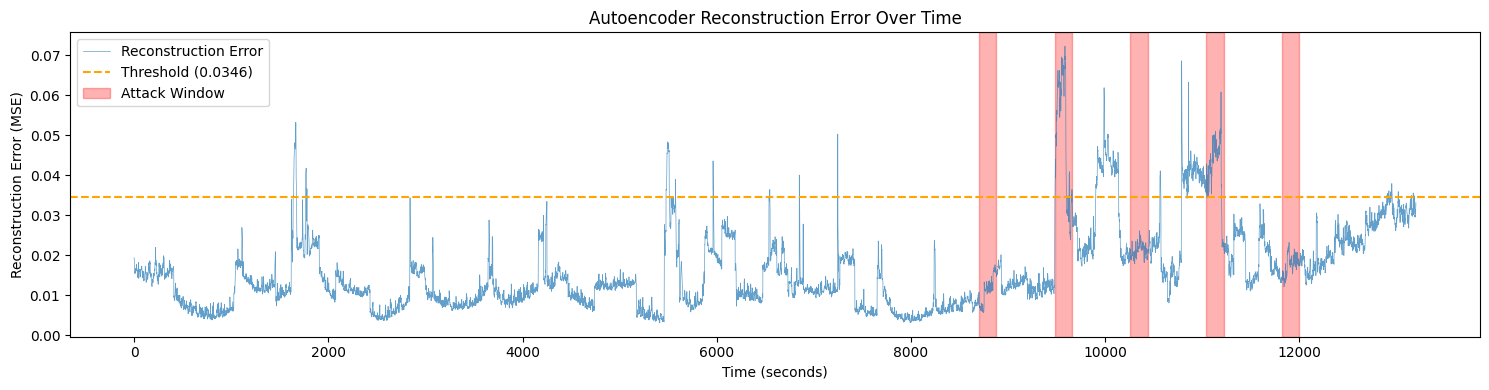

In [128]:
# Reconstruction Error Over Time for the Autoencoder Model
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(ae_reconstruction_errors, linewidth=0.5, label="Reconstruction Error", alpha=0.7)
ax.axhline(ae_threshold, color="orange", linestyle="--", label=f"Threshold ({ae_threshold:.4f})")

# Shade attack windows
attack_windows_idx = [
    (8700, 8880),   # 12:30 - 12:33
    (9480, 9660),   # 12:43 - 12:46
    (10260, 10440), # 12:56 - 12:59
    (11040, 11220), # 13:09 - 13:12
    (11820, 12000), # 13:22 - 13:25
]

for i, (start, end) in enumerate(attack_windows_idx):
    ax.axvspan(start, end, alpha=0.3, color="red",
               label="Attack Window" if i == 0 else "")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Reconstruction Error (MSE)")
ax.set_title("Autoencoder Reconstruction Error Over Time")
ax.legend()
plt.tight_layout()
plt.savefig("results/sensor_readings/reconstruction_error.png", dpi=150)
plt.show()

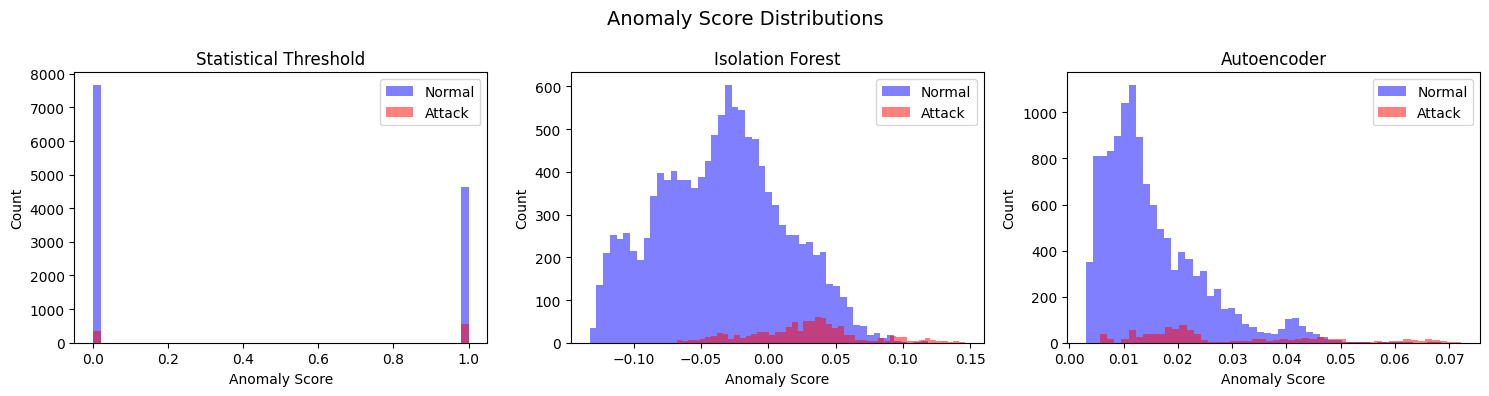

In [129]:
# Anomaly Score Distribution for Normal vs Attack Predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

score_data = [
    ("Statistical Threshold", threshold_predictions),
    ("Isolation Forest", iso_scores),
    ("Autoencoder", ae_reconstruction_errors),
]

for ax, (name, scores) in zip(axes, score_data):
    normal_scores = scores[Y_test_sensor_readings_labels == 0]
    attack_scores = scores[Y_test_sensor_readings_labels == 1]
    ax.hist(normal_scores, bins=50, alpha=0.5, label="Normal", color="blue")
    ax.hist(attack_scores, bins=50, alpha=0.5, label="Attack", color="red")
    ax.set_title(name)
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Anomaly Score Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("results/sensor_readings/score_distributions.png", dpi=150)
plt.show()

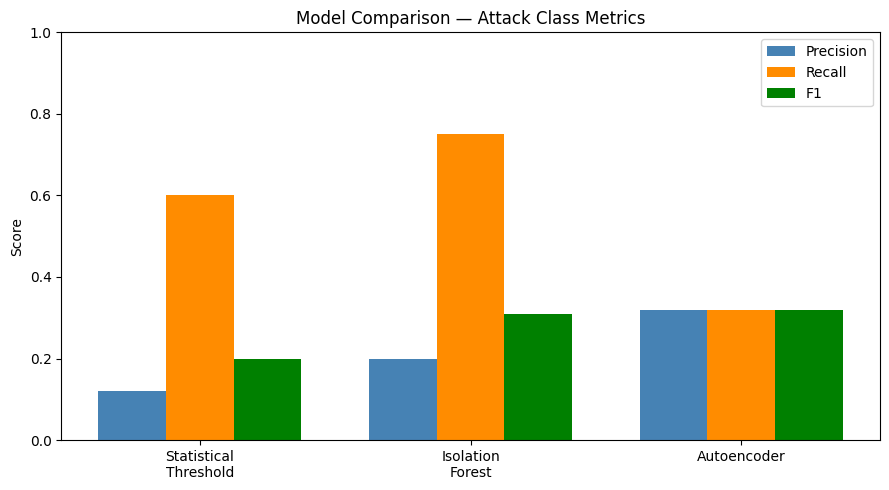

In [130]:

# F1, Precision, and Recall Bar Chart Model Comparisons
models_names = ["Statistical\nThreshold", "Isolation\nForest", "Autoencoder"]
precision_scores = [0.12, 0.20, 0.32]
recall_scores = [0.60, 0.75, 0.32]
f1_scores = [0.20, 0.31, 0.32]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, precision_scores, width, label="Precision", color="steelblue")
ax.bar(x, recall_scores, width, label="Recall", color="darkorange")
ax.bar(x + width, f1_scores, width, label="F1", color="green")

ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Attack Class Metrics")
ax.legend()
plt.tight_layout()
plt.savefig("results/sensor_readings/model_comparison.png", dpi=150)
plt.show()

## Network Readings Evaluations